In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage
from scipy.ndimage import gaussian_filter
import matplotlib
import pandas as pd
import seaborn as sns
matplotlib.rcParams['pdf.fonttype'] = 42

# functions
def hex_to_RGB(hex_str):
    """ #FFFFFF -> [255,255,255]"""
    #Pass 16 to the integer function for change of base
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):
    """
    Given two hex colors, returns a color gradient
    with n colors.
    """
    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


def get_color_gradient3(c1, c2, c3, n):
    """
    Given three hex colors, returns a color gradient
    with n colors.
    """
    assert n > 2
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    c3_rgb = np.array(hex_to_RGB(c3))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors1 = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    rgb_colors2 = [((1-mix)*c2_rgb + (mix*c3_rgb)) for mix in mix_pcts]
    rgb_colors = rgb_colors1+rgb_colors2
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]




from matplotlib.colors import LinearSegmentedColormap

path = '/Volumes/Elements/PTM_project/PIPS2/LongMD_400K/'

color1 = "#F8EDEB"
color3 = "#F49595"
num_points = 2000
grad = get_color_gradient(color1, color3, num_points)
cmap = LinearSegmentedColormap.from_list(name='test',colors=grad)

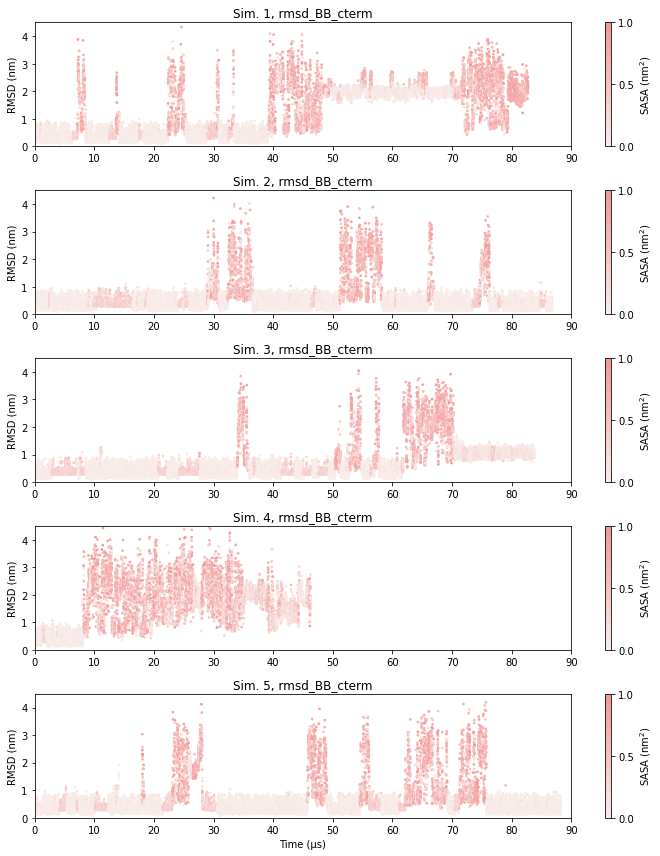

In [2]:

plt.figure(figsize = (10,12))
fontsize = 10

rmsd_type = 'rmsd_BB_cterm'

for sim in range(1,6):
    plt.subplot(5,1,sim)
    rmsd = np.loadtxt(path+'sim{}/{}.xvg'.format(sim, rmsd_type), skiprows=18)[:,1]
    SASA = np.loadtxt(path+'sim{}/sasa_SER96.xvg'.format(sim), skiprows=25)[:,2]
    time = np.loadtxt(path+'sim{}/sasa_SER96.xvg'.format(sim), skiprows=25)[:,0]/1e6 # us
    time = time[::10]
    rmsd = rmsd[::10]
    SASA = SASA[::10]


    sc = plt.scatter(time,rmsd,c = SASA,cmap=cmap,s=3, rasterized=True)
    plt.colorbar(sc,label = 'SASA (nm$^{2}$)',ticks=[0,0.5,1.0])
    plt.clim(0,1)
    plt.title('Sim. {}, {}'.format(sim, rmsd_type))
    if sim==5:
        plt.xlabel('Time (µs)',fontsize = fontsize)
    plt.ylabel('RMSD (nm)',fontsize = fontsize)
    plt.ylim(0,4.5)
    plt.xlim(0,90)

plt.tight_layout()
plt.savefig('{}_sasa_time.pdf'.format(rmsd_type), dpi=300)




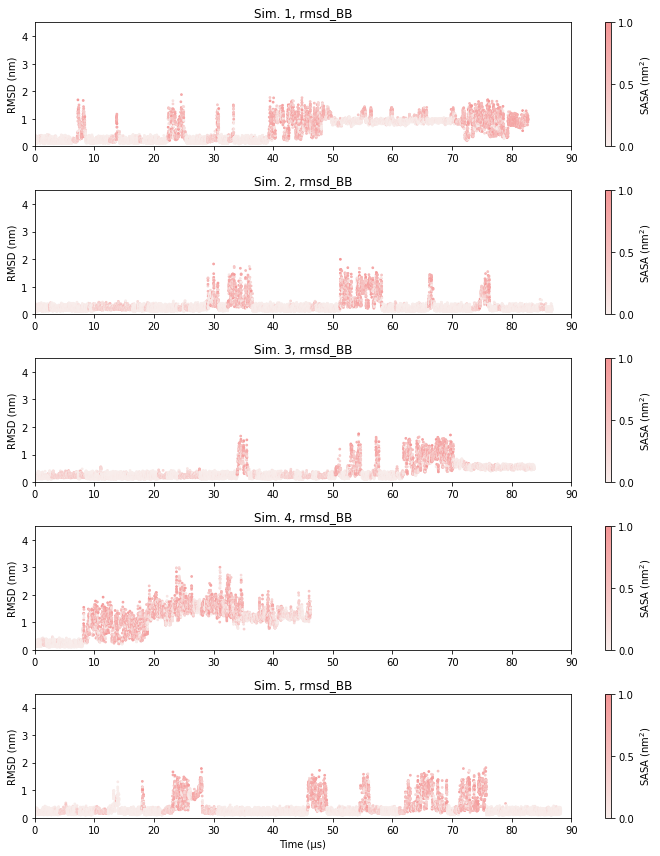

In [3]:

plt.figure(figsize = (10,12))
fontsize = 10

rmsd_type = 'rmsd_BB'

for sim in range(1,6):
    plt.subplot(5,1,sim)
    rmsd = np.loadtxt(path+'sim{}/{}.xvg'.format(sim, rmsd_type), skiprows=18)[:,1]
    SASA = np.loadtxt(path+'sim{}/sasa_SER96.xvg'.format(sim), skiprows=25)[:,2]
    time = np.loadtxt(path+'sim{}/sasa_SER96.xvg'.format(sim), skiprows=25)[:,0]/1e6 # us
    time = time[::10]
    rmsd = rmsd[::10]
    SASA = SASA[::10]


    sc = plt.scatter(time,rmsd,c = SASA,cmap=cmap,s=3, rasterized=True)
    plt.colorbar(sc,label = 'SASA (nm$^{2}$)',ticks=[0,0.5,1.0])
    plt.clim(0,1)
    plt.title('Sim. {}, {}'.format(sim, rmsd_type))
    if sim==5:
        plt.xlabel('Time (µs)',fontsize = fontsize)
    plt.ylabel('RMSD (nm)',fontsize = fontsize)
    plt.ylim(0,4.5)
    plt.xlim(0,90)

plt.tight_layout()
plt.savefig('{}_sasa_time.pdf'.format(rmsd_type), dpi=300)





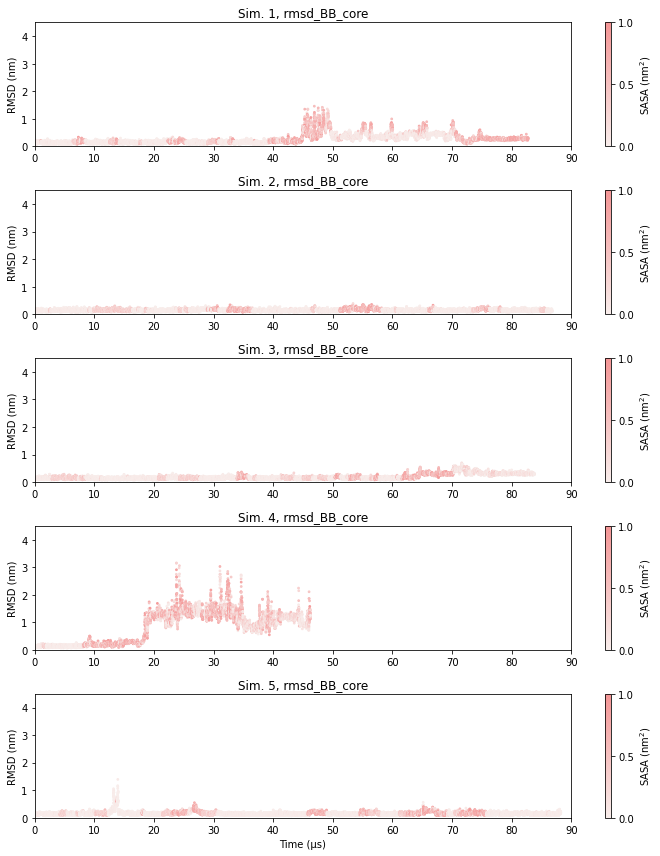

In [4]:

plt.figure(figsize = (10,12))
fontsize = 10

rmsd_type = 'rmsd_BB_core'

for sim in range(1,6):
    plt.subplot(5,1,sim)
    rmsd = np.loadtxt(path+'sim{}/{}.xvg'.format(sim, rmsd_type), skiprows=18)[:,1]
    SASA = np.loadtxt(path+'sim{}/sasa_SER96.xvg'.format(sim), skiprows=25)[:,2]
    time = np.loadtxt(path+'sim{}/sasa_SER96.xvg'.format(sim), skiprows=25)[:,0]/1e6 # us
    time = time[::10]
    rmsd = rmsd[::10]
    SASA = SASA[::10]


    sc = plt.scatter(time,rmsd,c = SASA,cmap=cmap,s=3, rasterized=True)
    plt.colorbar(sc,label = 'SASA (nm$^{2}$)',ticks=[0,0.5,1.0])
    plt.clim(0,1)
    plt.title('Sim. {}, {}'.format(sim, rmsd_type))
    if sim==5:
        plt.xlabel('Time (µs)',fontsize = fontsize)
    plt.ylabel('RMSD (nm)',fontsize = fontsize)
    plt.ylim(0,4.5)
    plt.xlim(0,90)

plt.tight_layout()
plt.savefig('{}_sasa_time.pdf'.format(rmsd_type), dpi=300)





0.5275581717719422


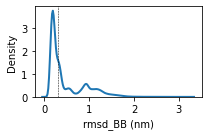

In [71]:


rmsd_type = 'rmsd_BB'
simstouse=[1,2,3,4,5]
for sim in simstouse:
    if sim==simstouse[0]:
        rmsd = np.loadtxt(path+'sim{}/{}.xvg'.format(sim, rmsd_type), skiprows=18)[:,1]
    else:
        tmprmsd = np.loadtxt(path+'sim{}/{}.xvg'.format(sim, rmsd_type), skiprows=18)[:,1]
        rmsd = np.concatenate((rmsd, tmprmsd), axis=0)
        
plt.figure(figsize =(3, 2))
cutoff=0.3
sns.kdeplot(rmsd, lw = 2)
plt.axvline(cutoff, linestyle='--', color='black', linewidth=0.5)
print(np.where(rmsd<cutoff)[0].shape[0]/rmsd.shape[0])
plt.xlabel('{} (nm)'.format(rmsd_type))
plt.ylabel('Density')
plt.tight_layout()
plt.savefig('dist_{}.pdf'.format(rmsd_type))

0.7648899749195686


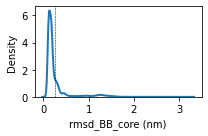

In [72]:


rmsd_type = 'rmsd_BB_core'
simstouse=[1,2,3,4,5]
for sim in simstouse:
    if sim==simstouse[0]:
        rmsd = np.loadtxt(path+'sim{}/{}.xvg'.format(sim, rmsd_type), skiprows=18)[:,1]
    else:
        tmprmsd = np.loadtxt(path+'sim{}/{}.xvg'.format(sim, rmsd_type), skiprows=18)[:,1]
        rmsd = np.concatenate((rmsd, tmprmsd), axis=0)
plt.figure(figsize =(3, 2))
cutoff=0.25
sns.kdeplot(rmsd, lw = 2)
plt.axvline(cutoff, linestyle='--', color='black', linewidth=0.5)
print(np.where(rmsd<cutoff)[0].shape[0]/rmsd.shape[0])
plt.xlabel('{} (nm)'.format(rmsd_type))
plt.ylabel('Density')
plt.tight_layout()
plt.savefig('dist_{}.pdf'.format(rmsd_type))

0.4644741168657842
0.33071611401602824


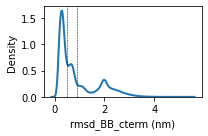

In [73]:


rmsd_type = 'rmsd_BB_cterm'
simstouse=[1,2,3,4,5]
for sim in simstouse:
    if sim==simstouse[0]:
        rmsd = np.loadtxt(path+'sim{}/{}.xvg'.format(sim, rmsd_type), skiprows=18)[:,1]
    else:
        tmprmsd = np.loadtxt(path+'sim{}/{}.xvg'.format(sim, rmsd_type), skiprows=18)[:,1]
        rmsd = np.concatenate((rmsd, tmprmsd), axis=0)
cutoff=0.5
cutoff2=0.9
plt.figure(figsize =(3, 2))

sns.kdeplot(rmsd, lw = 2)
plt.axvline(cutoff, linestyle='--', color='black', linewidth=0.5)
plt.axvline(cutoff2, linestyle='--', color='black', linewidth=0.5)
print(np.where(rmsd<cutoff)[0].shape[0]/rmsd.shape[0])
print(np.where(rmsd>cutoff2)[0].shape[0]/rmsd.shape[0])
plt.xlabel('{} (nm)'.format(rmsd_type))
plt.ylabel('Density')
plt.tight_layout()
plt.savefig('dist_{}.pdf'.format(rmsd_type))

/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:37: RuntimeWarning: divide by zero encountered in log
/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:61: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "rasterized" which is no longer supported as of 3.3 and will become an error in 3.6


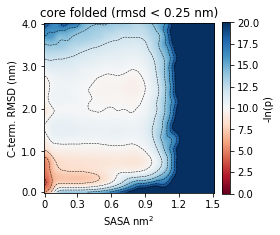

In [86]:
# 2D map: SASA vs rmsd types 
# analysing the native state basin only (core BB rmsd < 0.25 nm) 
# 2D histogram

rmsd_type = 'rmsd_BB_cterm'
simstouse=[1,2,3,4,5]
for sim in simstouse:
    if sim==simstouse[0]:
        rmsd = np.loadtxt(path+'sim{}/{}.xvg'.format(sim, rmsd_type), skiprows=18)[:,1]
        core = np.loadtxt(path+'sim{}/rmsd_BB_core.xvg'.format(sim), skiprows=18)[:,1]
        SASA = np.loadtxt(path+'sim{}/sasa_SER96.xvg'.format(sim), skiprows=25)[:,2]
    else:
        tmprmsd = np.loadtxt(path+'sim{}/{}.xvg'.format(sim, rmsd_type), skiprows=18)[:,1]
        tmpcore = np.loadtxt(path+'sim{}/rmsd_BB_core.xvg'.format(sim), skiprows=18)[:,1]
        tmpSASA = np.loadtxt(path+'sim{}/sasa_SER96.xvg'.format(sim), skiprows=25)[:,2]
        rmsd = np.concatenate((rmsd, tmprmsd), axis=0)
        core = np.concatenate((core, tmpcore), axis=0)
        SASA = np.concatenate((SASA, tmpSASA), axis=0)
    

# extract frames
cutoff = 0.25
frames = np.where(core<cutoff)[0]
rmsd = rmsd[frames]
SASA = SASA[frames]
    
xedges = np.arange(0,1.515,0.015) # sasa
yedges = np.arange(0,4.04,0.04) # rmsd



H, xedges, yedges = np.histogram2d(SASA,rmsd,bins=(xedges,yedges)) # H = counts per bin
H = gaussian_filter(H, sigma=2)
h = H/np.sum(H)
h = h.T

h = -np.log(h)
h = np.nan_to_num(h,posinf=100)
#h = h - np.min(h)

max_energy = 20

plt.figure(figsize = (4,4))

plt.imshow(h,origin='lower',cmap='RdBu', rasterized=True)
plt.clim(0,max_energy)
plt.colorbar(fraction=0.046, pad=0.04,label = '-ln(p)')
xlabels = [0,0.3,0.6,0.9, 1.2, 1.5]
ylabels = [0.0,1.0,2.0,3.0,4.0]
plt.xticks(ticks = [0,19,39,59,79,99],labels =xlabels)
plt.yticks(ticks = [0,24,49,74,99],labels =ylabels)

plt.contour(h,levels = np.arange(0,max_energy+2,2),colors = np.repeat(str('black'),max_energy/2),
                linewidths = np.repeat(0.5,max_energy/2), linestyles = np.repeat(str('dashed'),max_energy/2))

plt.title('core folded (rmsd < 0.25 nm)')
plt.xlabel('SASA nm$^{2}$')
plt.ylabel('C-term. RMSD (nm)')

plt.tight_layout()
plt.savefig('2D_{}_SASA_Ser96.pdf'.format(rmsd_type), rasterized=True)


In [104]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# calculate average SASA folded vs partially unfolded
# cterm rmsd < 0.5 nm = folded
# unfolded > 0.9 nm cterm rmsd

folded = np.where(rmsd < 0.5)[0]
unfolded = np.where(rmsd > 0.9)[0]


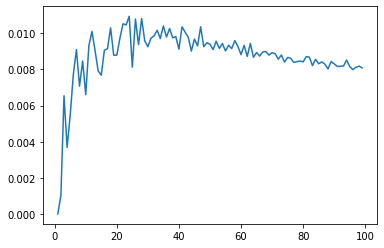

In [105]:
# errors on mean SASA values from blocking

vals = SASA[folded]

nblocks = np.arange(1, 100)
block_sizes = []
err = []
for n in nblocks:
    size = int(vals.shape[0]/n)
    block_sizes.append(size)
    means = []
    for i in range(n):
        b = vals[i*size:(i+1)*size]
        means.append(np.mean(b))
    err.append(np.std(means)/np.sqrt(n))
error_folded = np.mean(err[50:])
plt.plot(nblocks, err)

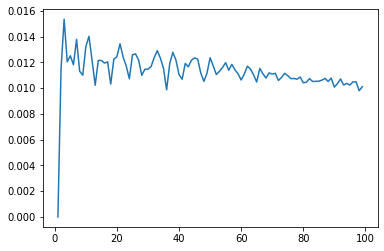

In [106]:
# errors on mean SASA values from blocking

vals = SASA[unfolded]

nblocks = np.arange(1, 100)
block_sizes = []
err = []
for n in nblocks:
    size = int(vals.shape[0]/n)
    block_sizes.append(size)
    means = []
    for i in range(n):
        b = vals[i*size:(i+1)*size]
        means.append(np.mean(b))
    err.append(np.std(means)/np.sqrt(n))
error_unfolded = np.mean(err[50:])
plt.plot(nblocks, err)

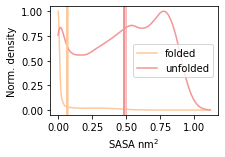

In [111]:
# common x grid
x = np.linspace(np.min(SASA), np.max(SASA), 500)

# KDEs
kde_folded = gaussian_kde(SASA[folded])
kde_unfolded = gaussian_kde(SASA[unfolded])

y_folded = kde_folded(x)
y_unfolded = kde_unfolded(x)

# normalize each by its own maximum
y_folded = y_folded / y_folded.max()
y_unfolded = y_unfolded / y_unfolded.max()

# means
mu_folded = np.mean(SASA[folded])
mu_unfolded = np.mean(SASA[unfolded])

# save data
df = pd.DataFrame()
df['SASA folded'] = [mu_folded]
df['SASA folded ±'] = [error_folded]
df['SASA unfolded'] = [mu_unfolded]
df['SASA unfolded ±'] = [error_unfolded]
df.to_csv('avg_SASA_folded_unfolded.csv')


# plot
plt.figure(figsize = (3,2))
plt.plot(x, y_folded, label="folded", color = '#FEC89A')
plt.plot(x, y_unfolded, label="unfolded", color = '#F49595')
plt.axvline(mu_folded, lw=2, color = '#FEC89A')
plt.axvline(mu_unfolded, lw=2, color = '#F49595')
plt.axvspan(mu_folded-error_folded, mu_folded+error_folded, color = '#FEC89A', alpha=0.5)
plt.axvspan(mu_unfolded-error_unfolded, mu_unfolded+error_unfolded, color = '#F49595', alpha=0.5)
plt.xlabel('SASA nm$^{2}$')
plt.ylabel("Norm. density")
plt.legend()
plt.savefig('SER96_SASA_dist_folded_unfolded.pdf')

In [112]:
df

,SASA folded,SASA folded ±,SASA unfolded,SASA unfolded ±
0,0.065622,0.008676,0.486447,0.010861
